In [ ]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')

# Path ke file ZIP di Google Drive
zip_path = '/content/drive/MyDrive/Colab Notebooks/Dataset/DATASET DIABETIC.zip'

# Ekstrak file ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/sample_data/diabet/')

# Tampilkan daftar file yang diekstrak
extracted_files = os.listdir('/content/sample_data/diabet/')
print("File yang diekstrak:", extracted_files)

Mounted at /content/drive
File yang diekstrak: ['DATASET DIABETIC']


## - Install Requirements

In [ ]:
!pip install pytorch-tabnet
!pip install xgboost
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install --upgrade scikit-learn xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

## - Import Liblary

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pytorch_tabnet.tab_model import TabNetClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

In [ ]:
import warnings

warnings.filterwarnings('ignore')

## 1. Muat Dataset

In [ ]:
def load_datasets(filepaths):
    datasets = [pd.read_csv(filepath) for filepath in filepaths]
    return datasets


## 2. Gabungkan Dataset

In [ ]:
def combine_datasets(datasets):
    df_comb = pd.concat(datasets, ignore_index=True)
    return df_comb

## 3. Mengubah Nama Column

In [ ]:
def rename_columns(df, column_names):
    df.columns = column_names
    return df

## 4. EDA

In [ ]:
def exploratory_data_analysis(df):
    print(df.info())
    print(df.describe())

    plt.figure(figsize=(8, 6))
    sns.countplot(x='Diagnosa', data=df)
    plt.title('Distribusi Label Diagnosa')
    plt.show()

    numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_columns].hist(bins=15, figsize=(15, 10))
    plt.show()

    plt.figure(figsize=(12, 8))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Heatmap Korelasi')
    plt.show()


## 5. Mengubah Nilai 0 Menjadi NaN

In [ ]:
def replace_zeros_with_nan(df, columns):
    for col in columns:
        zero_count = (df[col] == 0).sum()
        print(f'Jumlah nilai 0 pada {col}= {zero_count}')

        # Mengganti nilai 0 dengan NaN
        df[col].replace(0, np.nan, inplace=True)
        print()

        # Cek hasil penggantian
        print(f'Hasil kolom {col}:')
        print(df[col].value_counts(dropna=False))  # Gunakan dropna=False untuk melihat NaN
        print()

    # Cek jumlah NaN keseluruhan
    print('Jumlah NaN keseluruhan dalam DataFrame:')
    print(df.isnull().sum())

    return df

## 6. Mengubah Nilai NaN jadi Rata-Rata

In [ ]:
def replace_nan_with_mean(df, columns):
    for col in columns:
        nan_count = df[col].isnull().sum()
        print(f'Jumlah nilai NaN pada {col} = {nan_count}')

        # Menghitung rata-rata kolom
        mean_value = df[col].mean()

        # Mengganti nilai NaN dengan rata-rata
        df[col].fillna(mean_value, inplace=True)
        print()

        # Cek hasil penggantian
        print(f'Hasil kolom {col}:')
        print(df[col].value_counts(dropna=False))
        print()

    # Cek jumlah NaN keseluruhan
    print('Jumlah NaN keseluruhan dalam DataFrame:')
    print(df.isnull().sum())

    return df


## 7. Spliting Data

In [ ]:
def split_data(df, target_column, test_size=0.2, random_state=42):
    # Pisahkan data menjadi fitur (X) dan label (y)
    X = df.drop(target_column, axis=1)  # Fitur
    y = df[target_column]  # Label

    # Pisahkan data menjadi 80% pelatihan dan 20% pengujian
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    return X_train, X_test, y_train, y_test


## 8. Melatih TabNet

In [ ]:
def train_tabnet(X_train, y_train):
    from pytorch_tabnet.tab_model import TabNetClassifier

    # Buat model TabNet dengan parameter tetap
    clf = TabNetClassifier(n_d=16, n_a=16, n_steps=3, gamma=1.2, lambda_sparse=0.001)
    # 'gamma': 1.0, 'lambda_sparse': 0.1, 'n_a': 24, 'n_d': 8, 'n_steps': 3
    # n_d=16, n_a=16, n_steps=3, gamma=1.2, lambda_sparse=0.001
    # Latih model dengan data pelatihan
    clf.fit(
        X_train.values, y_train.values,
        max_epochs=100,
        patience=10,
        batch_size=1024,
        virtual_batch_size=128,
        eval_metric=['accuracy']
    )

    return clf

## 10. Melatih XGBoost

In [ ]:
def train_xgboost(X_train, y_train):
    # Buat model XGBoost
    xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

    # Latih model dengan data pelatihan
    xgb_clf.fit(X_train, y_train)

    return xgb_clf

## 11. Melatih RandomFoest

In [ ]:
def train_random_forest(X_train, y_train):
    # Buat model Random Forest
    rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

    # Latih model dengan data pelatihan
    rf_clf.fit(X_train, y_train)

    return rf_clf

## 12. Ensembel Model

In [ ]:
from sklearn.ensemble import VotingClassifier

def ensamble_models(xgb_clf, rf_clf):
    # Membuat Voting Classifier dengan ketiga model
    voting_clf = VotingClassifier(
        estimators=[
            ('XGBoost', xgb_clf),
            ('RandomForest', rf_clf)
        ],
        voting='soft'  # Menggunakan probabilitas prediksi (voting 'soft')
    )

    return voting_clf


## 13. Ensamble Manual

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix

def manual_ensamble(tabnet_clf, voting_clf, X_test):
    tabnet_pred = tabnet_clf.predict_proba(X_test.values)[:, 1]
    voting_pred = voting_clf.predict_proba(X_test.values)[:, 1]

    combined_predictions = (tabnet_pred + voting_pred) / 2
    final_predictions = (combined_predictions >= 0.5).astype(int)

    return final_predictions

def evaluate_ensamble(y_test, final_predictions):
    accuracy = accuracy_score(y_test, final_predictions)
    f1 = f1_score(y_test, final_predictions)
    precision = precision_score(y_test, final_predictions)
    recall = recall_score(y_test, final_predictions)
    roc_auc = roc_auc_score(y_test, final_predictions)

    print(f"Ensamble Accuracy: {accuracy:.2f}")
    print(f"Ensamble F1 Score: {f1:.2f}")
    print(f"Ensamble Precision: {precision:.2f}")
    print(f"Ensamble Recall: {recall:.2f}")
    print(f"Ensamble ROC AUC: {roc_auc:.2f}")

    print("Classification Report:")
    print(classification_report(y_test, final_predictions))

    print("Ensemble Confusion Matrix:")
    conf_mat = confusion_matrix(y_test, final_predictions)
    print(conf_mat)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Ensemble Confusion Matrix")
    plt.show()

## 14. Evaluasi Model

In [ ]:
def evaluate_models(models, X_test, y_test):
    results = {}
    for model_name, model in models.items():
        # Prediksi pada data pengujian
        y_pred = model.predict(X_test.values)
        y_proba = model.predict_proba(X_test.values)[:, 1]

        # Evaluasi hasil prediksi
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)

        print(f"{model_name} Accuracy: {accuracy:.2f}")
        print(f"{model_name} F1 Score: {f1:.2f}")
        print(f"{model_name} Precision: {precision:.2f}")
        print(f"{model_name} Recall: {recall:.2f}")
        print(f"{model_name} ROC AUC: {roc_auc:.2f}")

        print("Classification Report:")
        print(classification_report(y_test, y_pred))

        print("Confusion Matrix:")
        conf_mat = confusion_matrix(y_test, y_pred)
        print(conf_mat)

        # Plot Confusion Matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'{model_name} Confusion Matrix')
        plt.show()

        results[model_name] = {
            'accuracy': accuracy,
            'f1_score': f1,
            'precision': precision,
            'recall': recall,
            'roc_auc': roc_auc
        }
        print()
        print()

    return results

## 15. Save Model

In [ ]:
import joblib

def save_model(model, filename):
    joblib.dump(model, filename)

## 16. MAIN Execution

Jumlah nilai 0 pada Glukosa= 18

Hasil kolom Glukosa:
Glukosa
99.000000     66
100.000000    61
102.000000    52
129.000000    51
106.000000    50
              ..
123.798228     1
83.851292      1
99.781243      1
56.713803      1
87.647268      1
Name: count, Length: 1136, dtype: int64

Jumlah nilai 0 pada Tekanan_Darah= 125

Hasil kolom Tekanan_Darah:
Tekanan_Darah
70.000000     201
74.000000     197
78.000000     173
68.000000     170
64.000000     163
             ... 
108.869531      1
70.509170       1
90.732356       1
72.409521       1
69.111593       1
Name: count, Length: 1047, dtype: int64

Jumlah nilai 0 pada Ketebalan_Kulit= 800

Hasil kolom Ketebalan_Kulit:
Ketebalan_Kulit
NaN          800
32.000000    114
30.000000    102
23.000000     82
27.000000     81
            ... 
22.403553      1
25.698646      1
22.519621      1
23.400928      1
25.621266      1
Name: count, Length: 1053, dtype: int64

Jumlah nilai 0 pada Insulin= 1330

Hasil kolom Insulin:
Insulin
NaN        

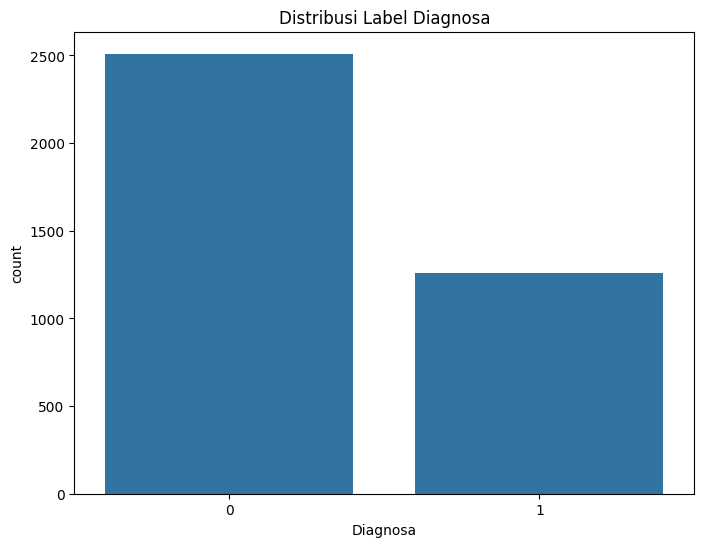

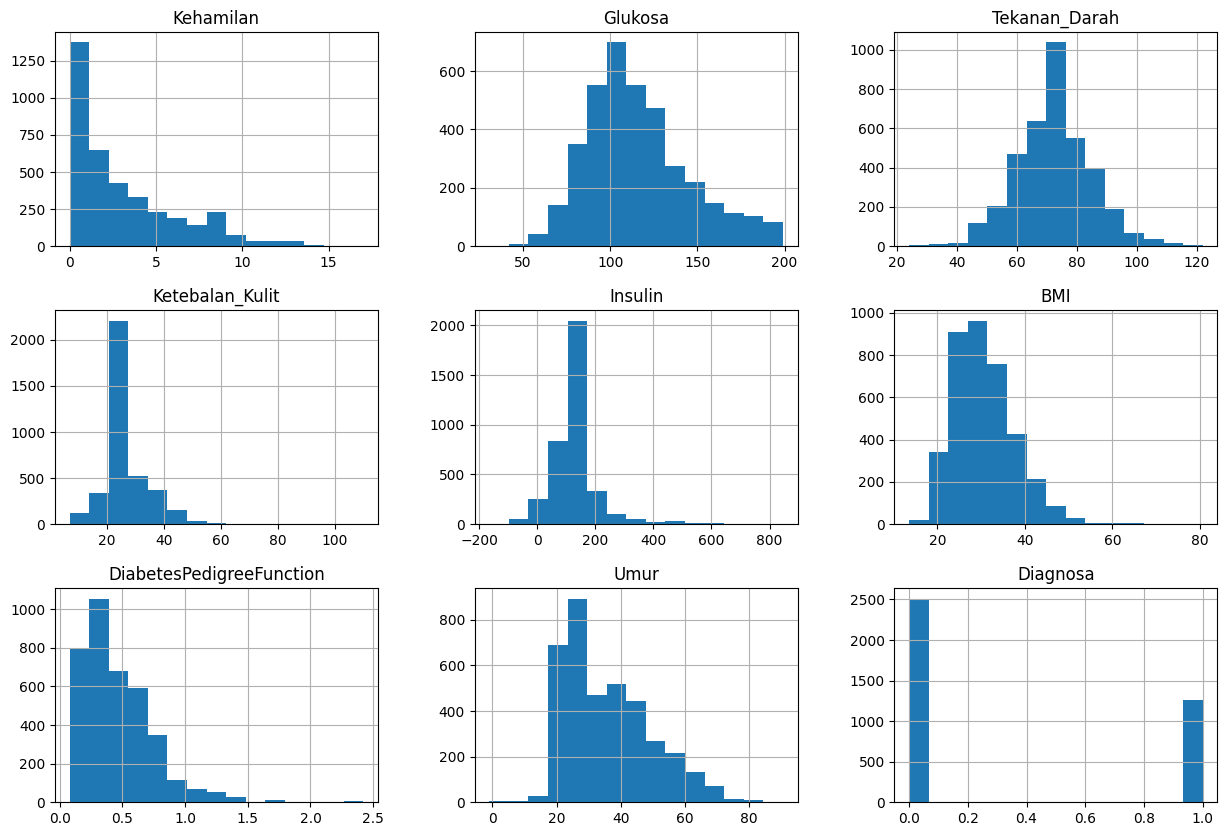

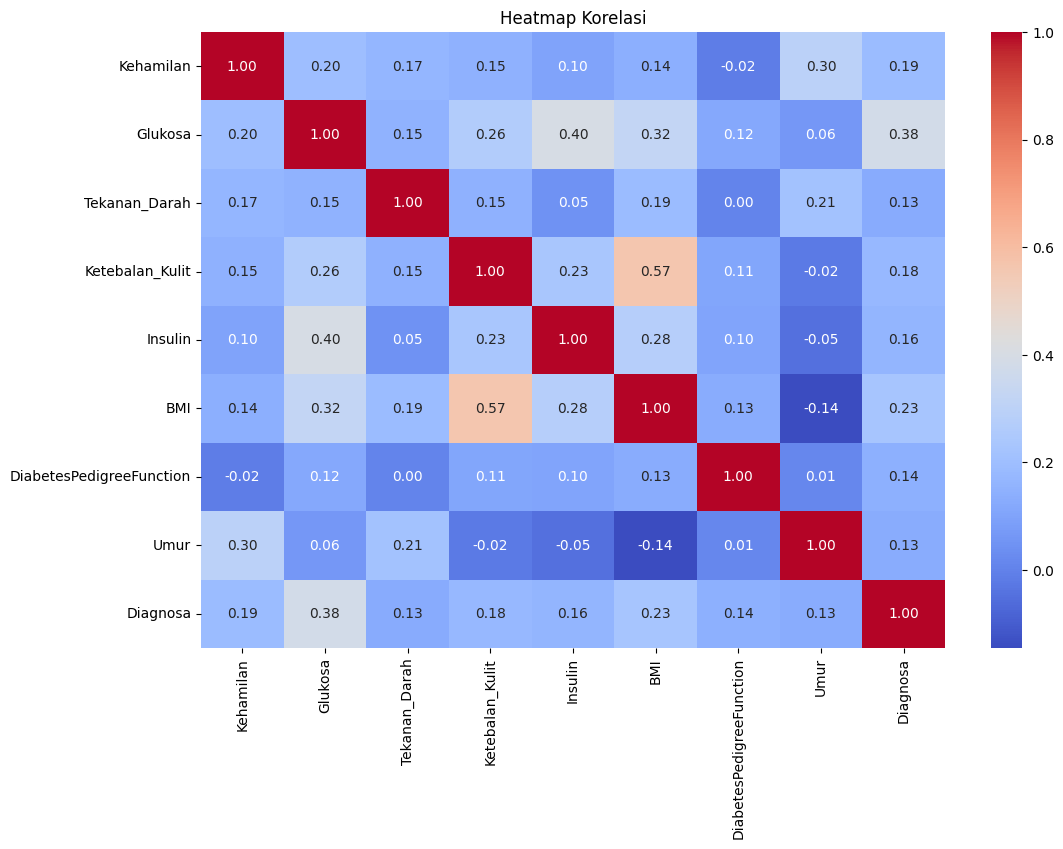

Latih dan evaluasi model TabNet dengan parameter default:

epoch 0  | loss: 0.82066 |  0:00:00s
epoch 1  | loss: 0.6068  |  0:00:00s
epoch 2  | loss: 0.60257 |  0:00:01s
epoch 3  | loss: 0.56326 |  0:00:01s
epoch 4  | loss: 0.54893 |  0:00:01s
epoch 5  | loss: 0.54477 |  0:00:01s
epoch 6  | loss: 0.54178 |  0:00:01s
epoch 7  | loss: 0.52964 |  0:00:02s
epoch 8  | loss: 0.5315  |  0:00:02s
epoch 9  | loss: 0.51737 |  0:00:02s
epoch 10 | loss: 0.50599 |  0:00:02s
epoch 11 | loss: 0.49732 |  0:00:03s
epoch 12 | loss: 0.50165 |  0:00:03s
epoch 13 | loss: 0.49773 |  0:00:03s
epoch 14 | loss: 0.48385 |  0:00:04s
epoch 15 | loss: 0.48785 |  0:00:04s
epoch 16 | loss: 0.4852  |  0:00:04s
epoch 17 | loss: 0.50023 |  0:00:04s
epoch 18 | loss: 0.48408 |  0:00:05s
epoch 19 | loss: 0.47655 |  0:00:06s
epoch 20 | loss: 0.47881 |  0:00:06s
epoch 21 | loss: 0.47213 |  0:00:07s
epoch 22 | loss: 0.45886 |  0:00:07s
epoch 23 | loss: 0.47559 |  0:00:08s
epoch 24 | loss: 0.46081 |  0:00:09s
epoch 25 | loss:

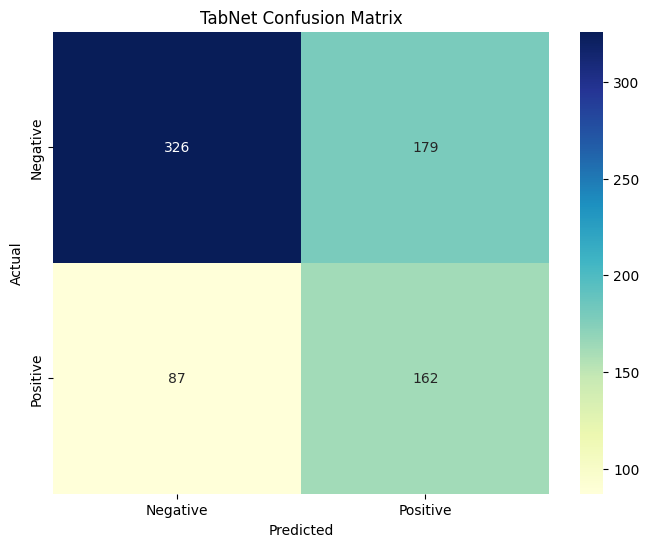



XGBoost Accuracy: 0.91
XGBoost F1 Score: 0.86
XGBoost Precision: 0.91
XGBoost Recall: 0.81
XGBoost ROC AUC: 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       505
           1       0.91      0.81      0.86       249

    accuracy                           0.91       754
   macro avg       0.91      0.88      0.89       754
weighted avg       0.91      0.91      0.91       754

Confusion Matrix:
[[485  20]
 [ 48 201]]


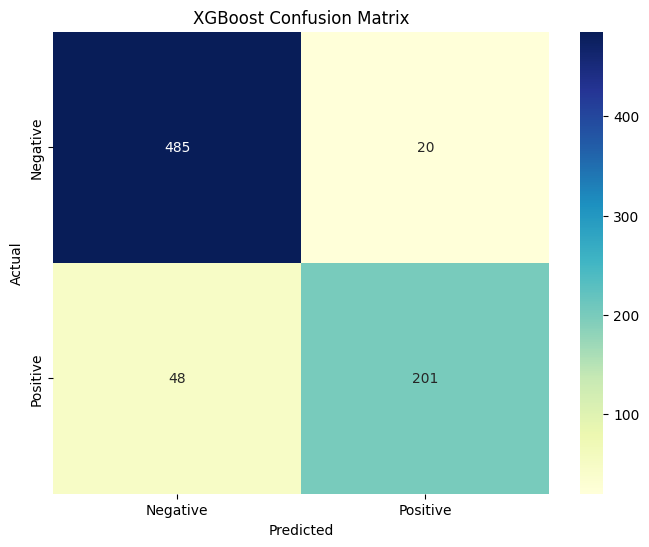



Random Forest Accuracy: 0.92
Random Forest F1 Score: 0.87
Random Forest Precision: 0.98
Random Forest Recall: 0.78
Random Forest ROC AUC: 0.97
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.95       505
           1       0.98      0.78      0.87       249

    accuracy                           0.92       754
   macro avg       0.94      0.89      0.91       754
weighted avg       0.93      0.92      0.92       754

Confusion Matrix:
[[501   4]
 [ 54 195]]


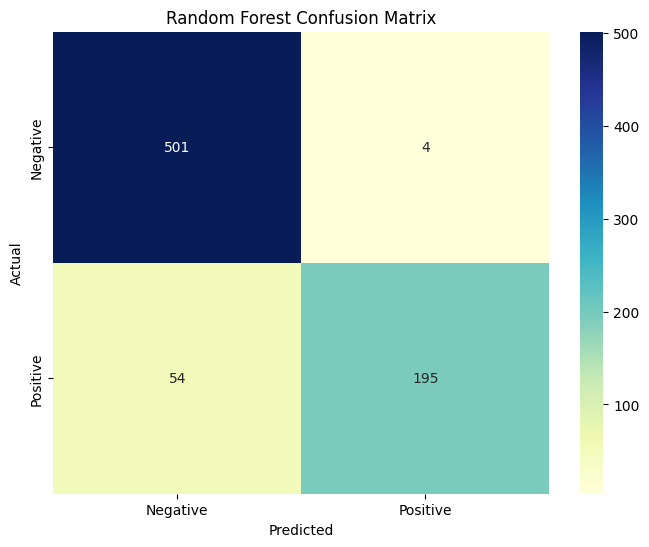



Latih dan evaluasi model VotingClassifier:

Ensamble Accuracy: 0.88
Ensamble F1 Score: 0.80
Ensamble Precision: 0.84
Ensamble Recall: 0.77
Ensamble ROC AUC: 0.85
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       505
           1       0.84      0.77      0.80       249

    accuracy                           0.88       754
   macro avg       0.86      0.85      0.86       754
weighted avg       0.87      0.88      0.87       754

Ensemble Confusion Matrix:
[[468  37]
 [ 57 192]]


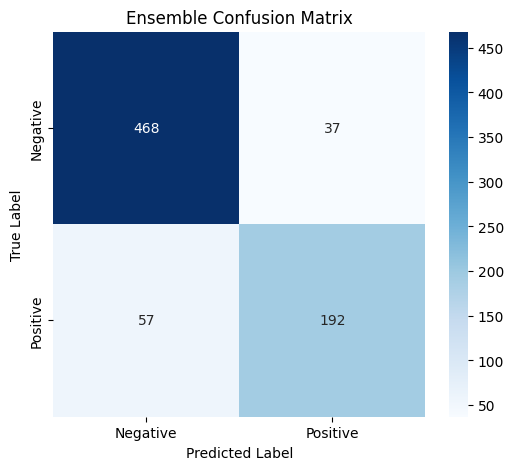

Model ensembel (VotingClassifier) disimpan sebagai 'TabNetClasiffication.pkl'


In [ ]:
def main(file_paths, column_names, target_column):
    # Load datasets
    datasets = load_datasets(file_paths)

    # Combine datasets
    df_comb = combine_datasets(datasets)

    # Rename columns
    df_comb = rename_columns(df_comb, column_names)

    # Replace zeros with NaN
    columns_to_replace = ['Glukosa', 'Tekanan_Darah', 'Ketebalan_Kulit', 'Insulin', 'BMI']
    df_comb = replace_zeros_with_nan(df_comb, columns_to_replace)

    # Replace NaNs (former 0s) with mean
    df_comb = replace_nan_with_mean(df_comb, columns_to_replace)

    # Perform EDA
    exploratory_data_analysis(df_comb)

    # Preprocess and Train-Test Split
    X_train, X_test, y_train, y_test = split_data(df_comb, target_column)

    # Latih model TabNet dengan parameter default
    print("Latih dan evaluasi model TabNet dengan parameter default:")
    print()
    tabnet_clf_default = train_tabnet(X_train, y_train)
    print()
    # Latih model XGBoost dan Random Forest
    print("Latih model XGBoost dan Random Forest:")
    print()
    xgb_clf = train_xgboost(X_train, y_train)
    rf_clf = train_random_forest(X_train, y_train)

    # Evaluasi model individu
    print("Evaluasi model individu:")
    print()
    models = {
        "TabNet": tabnet_clf_default,
        "XGBoost": xgb_clf,
        "Random Forest": rf_clf
    }
    evaluate_models(models, X_test, y_test)

    # Buat VotingClassifier dengan instance yang benar
    voting_clf = ensamble_models(xgb_clf, rf_clf)
    print("Latih dan evaluasi model VotingClassifier:")
    print()
    # Latih VotingClassifier pada data pelatihan
    voting_clf.fit(X_train.values, y_train.values)

    # Gabungkan prediksi dari TabNetClassifier secara manual dengan prediksi dari VotingClassifier
    final_predictions = manual_ensamble(tabnet_clf_default, voting_clf, X_test)

    # Evaluasi hasil ensamble
    evaluate_ensamble(y_test, final_predictions)

    # Simpan model ensembel
    joblib.dump(voting_clf, "TabNetClasiffication.pkl")
    print("Model ensembel (VotingClassifier) disimpan sebagai 'TabNetClasiffication.pkl'")

# Define the file paths and column names
file_paths = [
    "/content/sample_data/diabet/DATASET DIABETIC/diabetes-dataset-1.csv",
    "/content/sample_data/diabet/DATASET DIABETIC/diabetes-dataset-2.csv",
    "/content/sample_data/diabet/DATASET DIABETIC/diabetes-dataset-3.csv"
]
col_names = ['Kehamilan', 'Glukosa', 'Tekanan_Darah', 'Ketebalan_Kulit', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Umur', 'Diagnosa']
target_column = 'Diagnosa'

# Jalankan Main Execution di Akhir
if __name__ == "__main__":
    main(file_paths, col_names, target_column)
